In [1]:
import pandas as pd 
import requests as requests
from bs4 import BeautifulSoup
import numpy as np 
from sqlalchemy import create_engine
import re
import time
from bs4.element import NavigableString
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: First, find the total number of pages dynamically (optional)


In [16]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9,ar;q=0.8",
    "Accept-Encoding": "gzip, deflate, br",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Connection": "keep-alive",
    "DNT": "1",  # Do Not Track
    "Upgrade-Insecure-Requests": "1"
}
base_url = "https://www.amazon.eg/-/en/s?i=electronics&rh=n%3A21832883031&s=popularity-rank&fs=true&page={}&language=en&xpid=Db9GezKQmnfl2"



In [17]:
amazon_smartphones = []           

for page in range(1, 21):
    print(f"🔄 Scraping Page {page}")
    url  = base_url.format(page)

    res  = requests.get(url, headers=headers, timeout=15)
    soup = BeautifulSoup(res.content, "html.parser")

    #find names  and prices
    names  = soup.find_all("h2", attrs={"aria-label": True})
    prices = soup.find_all("span", class_="a-price-whole")

    
    for n_tag, p_tag in zip(names, prices):
        phone = {
            "name"  : n_tag["aria-label"].strip(),      
            "price" : p_tag.get_text(strip=True)        
        }
        amazon_smartphones.append(phone)
    

🔄 Scraping Page 1
🔄 Scraping Page 2
🔄 Scraping Page 3
🔄 Scraping Page 4
🔄 Scraping Page 5
🔄 Scraping Page 6
🔄 Scraping Page 7
🔄 Scraping Page 8
🔄 Scraping Page 9
🔄 Scraping Page 10
🔄 Scraping Page 11
🔄 Scraping Page 12
🔄 Scraping Page 13
🔄 Scraping Page 14
🔄 Scraping Page 15
🔄 Scraping Page 16
🔄 Scraping Page 17
🔄 Scraping Page 18
🔄 Scraping Page 19
🔄 Scraping Page 20


In [18]:
df = pd.DataFrame(amazon_smartphones)
df.to_csv(r"D:\projects\ecommerce_phones_project\amazon_smartphones.csv", index=False, encoding="utf-8-sig")


## EDA


In [92]:
df=pd.read_csv(r"D:\projects\ecommerce_phones_project\amazon_smartphones.csv")

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   name     232 non-null    object 
 1   price    232 non-null    float64
 2   Model    200 non-null    object 
 3   RAM      107 non-null    object 
 4   Storage  182 non-null    float64
dtypes: float64(2), object(3)
memory usage: 9.2+ KB


In [40]:
df.head()

,name,price
0,"Xiaomi Redmi A3, 3GB RAM | 64GB ROM, 6.71 Inch...",3666.0
1,"Samsung Galaxy A05s, Android Smartphone, Dual ...",5590.0
2,Samsung Galaxy A06 Dual Sim 6GB RAM 128GB Stor...,5666.0
3,Apple iPhone 13 (128 GB) - Midnight with Face ...,29999.0
4,"Samsung Galaxy A16 LTE, Android Smartphone, Du...",9754.0


In [23]:
df["price"]=df["price"].str.replace(r"[,.]","",regex=True)



In [27]:
df["price"]=df["price"].astype(float)


C:\Users\DEll\AppData\Local\Temp\ipykernel_15616\1644624127.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


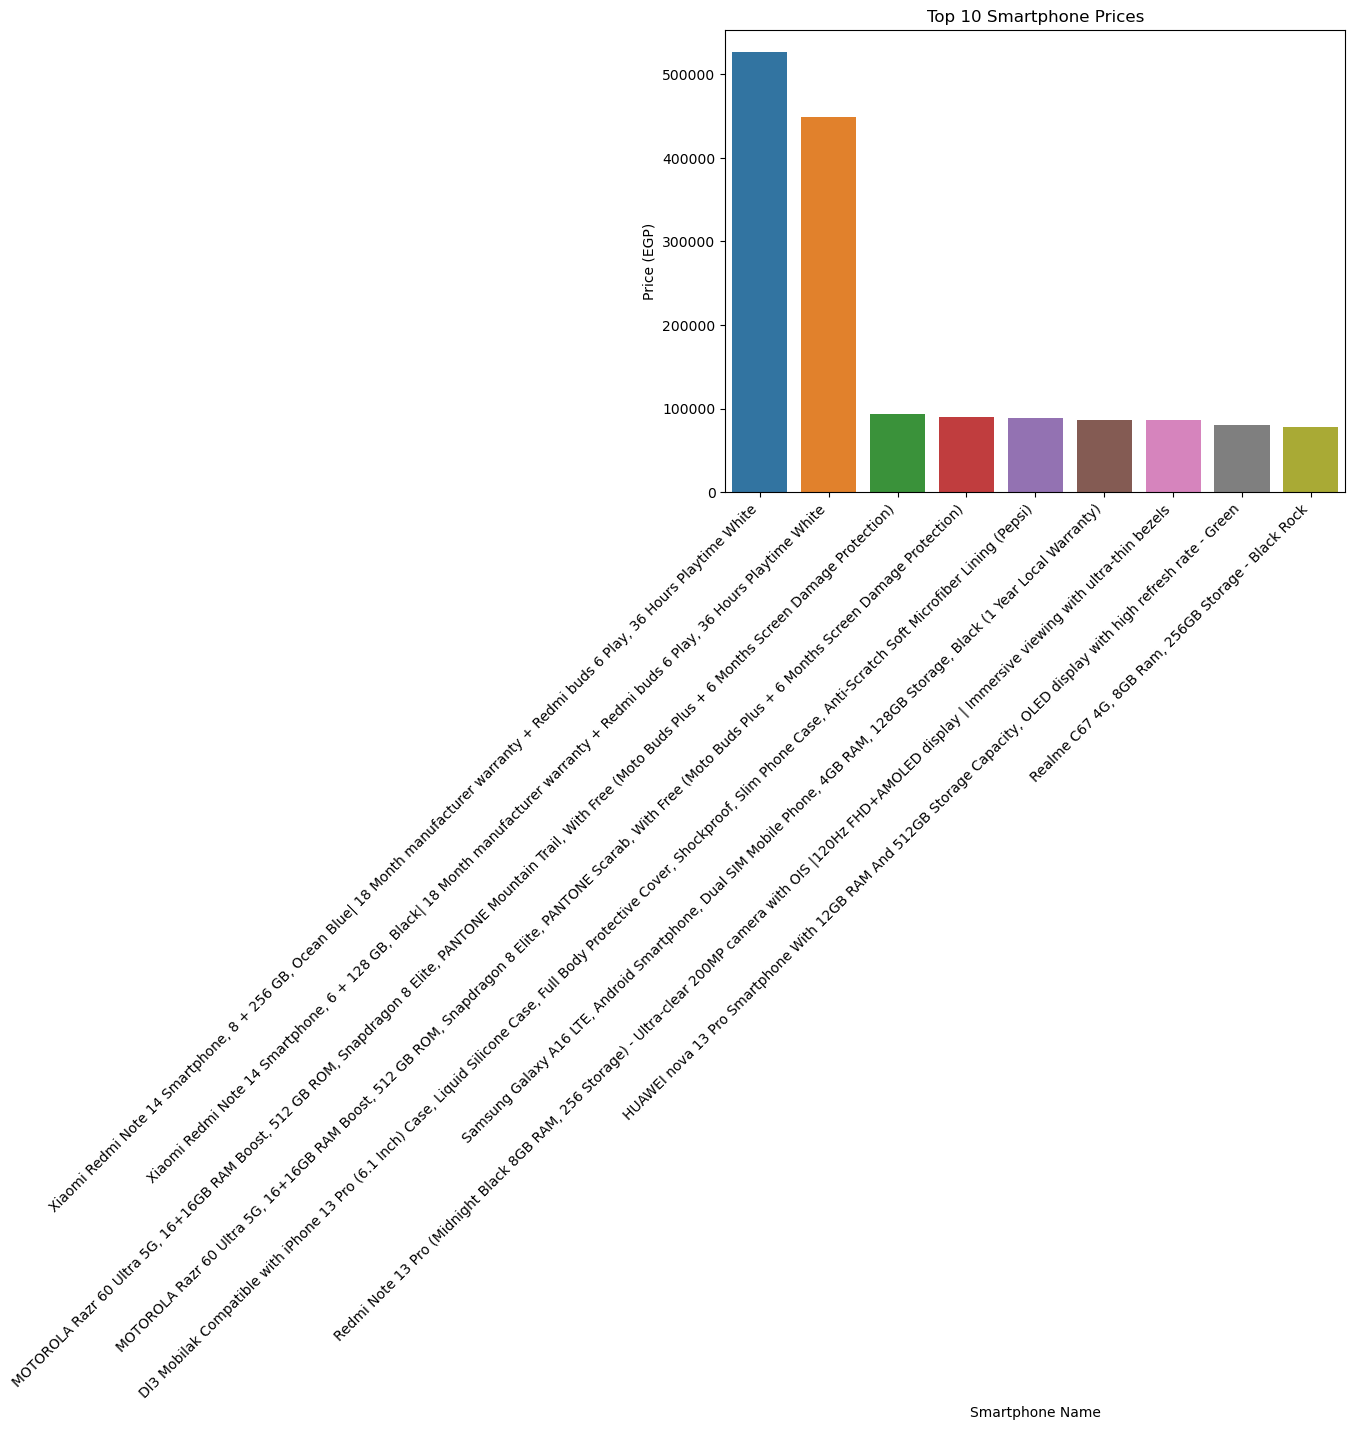

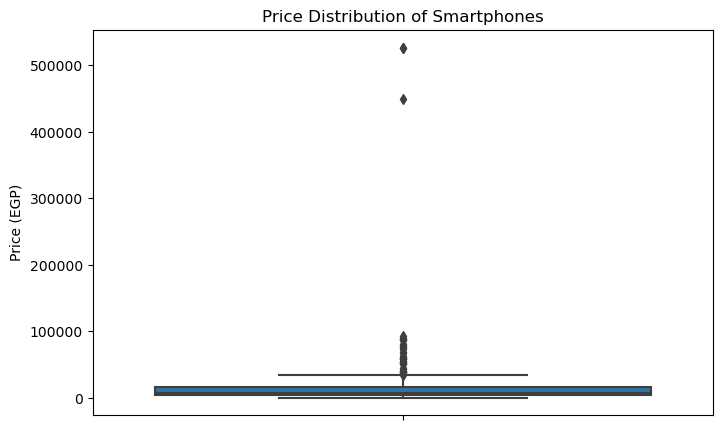

In [ ]:
plt.figure(figsize=(8, 6))
top10 = df.sort_values('price', ascending=False).head(10)
sns.barplot(x="name", y="price", data=top10, )
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Smartphone Prices")
plt.ylabel("Price (EGP)")
plt.xlabel("Smartphone Name")
plt.tight_layout()
plt.show()

# Boxplot: price distribution
plt.figure(figsize=(8, 5))
sns.boxplot(y="price", data=df)


In [2]:
df=pd.read_csv(r"D:\projects\ecommerce_phones_project\amazon_smartphones.csv")

In [ ]:
plt.title("Price Distribution of Smartphones")
plt.ylabel("Price (EGP)")
plt.show()

In [90]:
df.drop(df[df["price"] < 2500].index, inplace=True)


In [39]:

indexes_to_drop = df[df['name'].str.contains(r'[\u0600-\u06FF]', regex=True)].index
df = df.drop(indexes_to_drop)

In [ ]:
split_df = df['name'].str.split(' ', expand=True)
split_df


In [68]:
split_df["name"] = np.where(
    split_df[2] == "Note",
    split_df[0] + split_df[1] + split_df[2] + split_df[3],
    split_df[0] + split_df[1] + split_df[2]
)

In [27]:
split_df.drop(split_df.columns[17:], axis=1, inplace=True)

In [70]:
split_df.to_csv(r"D:\projects\ecommerce_phones_project\amazon_smartphones_split.csv", index=False)


In [72]:
brands = [
    "Samsung", "Xiaomi", "Infinix", "Apple", "OPPO", "Realme", "realme", "Vivo", "Itel", "itel",
    "Motorola", "Nokia", "HONOR", "Nothing", "Redmi", "POCO", "Tecno", "Blackview", "Asus",
    "CUBOT", "AllCall", "HUAWEI", "G-tide", "Girasole", "CMF", "DOOGEE", "ZTE"
]
brand_pattern = '|'.join(brands)


In [142]:
# Example regex for model, RAM, storage
df['Model'] = split_df['name']
df['Storage'] =  df['name'].str.extract(r'(32|64|128|256|512)')
df["brand"]=     df['name'].str.extract(f'({brand_pattern})', flags=re.IGNORECASE)




In [140]:
df['RAM'] = df['name'].str.extract(
    r'(?i)(?:\(|\b)(\d{1,2})(?:\s?\+\s?\d{1,2})?\s?GB\s?(?=ram|/|\+|\||\)|,| ROM|$)'
)

# Clean and standardize: Add GB suffix
df['RAM'] = df['RAM'].fillna('').apply(lambda x: x + 'GB' if x else None)


In [143]:
df.info()



<class 'pandas.core.frame.DataFrame'>
Index: 190 entries, 0 to 231
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   name     190 non-null    object 
 1   price    190 non-null    float64
 2   Model    190 non-null    object 
 3   RAM      131 non-null    object 
 4   Storage  172 non-null    object 
 5   brand    190 non-null    object 
dtypes: float64(1), object(5)
memory usage: 14.5+ KB


In [116]:
df["RAM"]

0      3GB
1      6GB
2      6GB
3         
4      8GB
      ... 
223       
224       
225       
229       
231       
Name: RAM, Length: 190, dtype: object

In [145]:
df.to_csv(r"D:\projects\ecommerce_phones_project\amazon_smartphones.csv", index=False)